In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("Dataset.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [6]:
print("\nShape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:\n", df.head())


Shape of dataset: (1092, 10)

Columns: ['timestamp', 'region', 'service_line', 'resource_demand', 'capacity_planned', 'operational_spend_usd', 'reliability_score', 'gdp_growth_rate', 'tech_investment_index', 'cloud_sentiment_score']

First 3 rows:
     timestamp         region service_line  resource_demand  capacity_planned  \
0  2024-01-01        East US      Compute           644.69               818   
1  2024-01-01        East US      Storage          1102.71              1400   
2  2024-01-01    West Europe      Compute           597.55               758   
3  2024-01-01    West Europe      Storage           979.71              1244   
4  2024-01-01  Central India      Compute           503.19               639   

   operational_spend_usd  reliability_score  gdp_growth_rate  \
0                 361.03             99.804             2.06   
1                 154.38             99.571             2.06   
2                 334.63             99.727             2.08   
3            

In [7]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 timestamp                 0
region                    0
service_line              0
resource_demand          22
capacity_planned          0
operational_spend_usd     0
reliability_score         0
gdp_growth_rate          22
tech_investment_index    22
cloud_sentiment_score     0
dtype: int64


In [8]:
# Fill numeric columns with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
df = df.drop_duplicates()
print("\nDuplicates removed")


Duplicates removed


In [10]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
print("\nColumn names standardized")


Column names standardized


In [11]:
for col in df.columns:
    if "date" in col or "time" in col:
        df[col] = pd.to_datetime(df[col])

In [12]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df = df[df[col] >= 0]

print("Negative values removed successfully")


Negative values removed successfully


In [13]:
for col in df.columns:
    if "date" in col or "time" in col:
        df["year"] = df[col].dt.year
        df["month"] = df[col].dt.month
        df["day"] = df[col].dt.day



Before Cleaning Summary:
                 timestamp  resource_demand  capacity_planned  \
count                 1092      1092.000000       1092.000000   
mean   2024-03-31 12:00:00       784.407958        992.684982   
min    2024-01-01 00:00:00       466.190000        592.000000   
25%    2024-02-15 00:00:00       581.420000        735.000000   
50%    2024-03-31 12:00:00       811.350000        956.000000   
75%    2024-05-16 00:00:00       976.637500       1241.000000   
max    2024-06-30 00:00:00      1168.180000       1483.000000   
std                    NaN       221.722926        284.752144   

       operational_spend_usd  reliability_score  gdp_growth_rate  \
count            1092.000000        1092.000000      1092.000000   
mean              231.490394          99.704892         2.179643   
min               112.690000          99.400000         1.850000   
25%               136.880000          99.561000         2.080000   
50%               212.305000          99.708500 

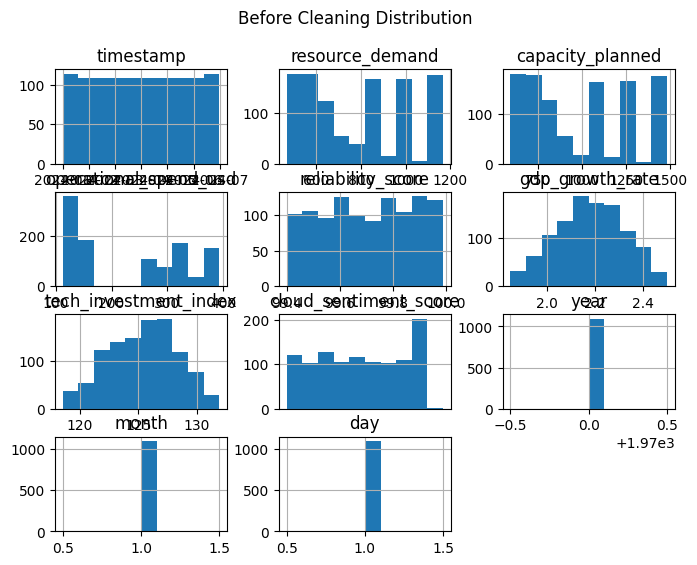

In [16]:
print("\nBefore Cleaning Summary:")
print(df.describe())
import matplotlib.pyplot as plt

df.hist(figsize=(8,6))
plt.suptitle("Before Cleaning Distribution")
plt.show()



After Cleaning Summary:
                 timestamp  resource_demand  capacity_planned  \
count                 1092      1092.000000       1092.000000   
mean   2024-03-31 12:00:00       784.407958        992.684982   
min    2024-01-01 00:00:00       466.190000        592.000000   
25%    2024-02-15 00:00:00       581.420000        735.000000   
50%    2024-03-31 12:00:00       811.350000        956.000000   
75%    2024-05-16 00:00:00       976.637500       1241.000000   
max    2024-06-30 00:00:00      1168.180000       1483.000000   
std                    NaN       221.722926        284.752144   

       operational_spend_usd  reliability_score  gdp_growth_rate  \
count            1092.000000        1092.000000      1092.000000   
mean              231.490394          99.704892         2.179643   
min               112.690000          99.400000         1.850000   
25%               136.880000          99.561000         2.080000   
50%               212.305000          99.708500  

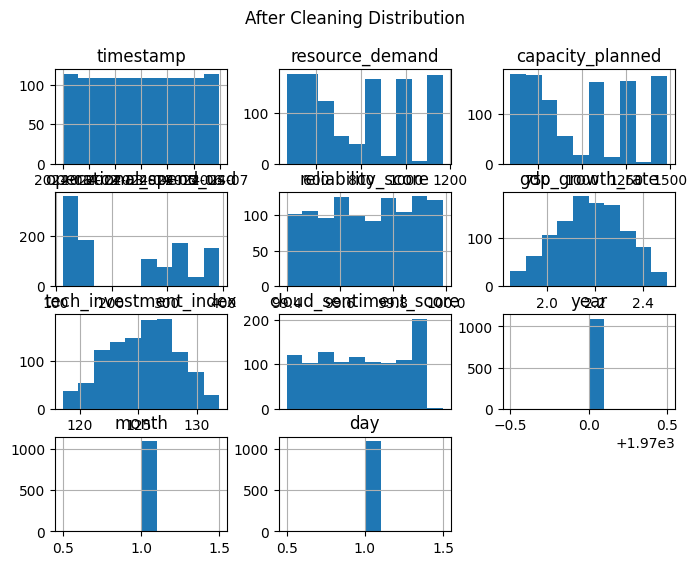

In [17]:
print("\nAfter Cleaning Summary:")
print(df.describe())

df.hist(figsize=(8,6))
plt.suptitle("After Cleaning Distribution")
plt.show()


In [18]:
df.to_csv("cleaned_dataset.csv", index=False)
print("\nCleaned dataset saved successfully")


Cleaned dataset saved successfully


**MILESTONE - 2**

In [20]:
df = pd.read_csv("cleaned_dataset.csv")

print(df.columns)

Index(['timestamp', 'region', 'service_line', 'resource_demand',
       'capacity_planned', 'operational_spend_usd', 'reliability_score',
       'gdp_growth_rate', 'tech_investment_index', 'cloud_sentiment_score',
       'year', 'month', 'day'],
      dtype='object')


In [34]:
date_col = [col for col in df.columns if "date" in col or "time" in col][0]

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)
print(df)

      timestamp  resource_demand  capacity_planned  operational_spend_usd  \
13   2024-01-03          1129.05              1433                 158.07   
16   2024-01-03           490.43               622                 274.64   
17   2024-01-03           844.80              1072                 118.27   
15   2024-01-03           994.82              1263                 139.27   
22   2024-01-04           503.82               639                 282.14   
...         ...              ...               ...                    ...   
1089 2024-06-30           978.94              1243                 137.05   
1090 2024-06-30           518.73               658                 290.49   
1086 2024-06-30           811.35               871                 384.10   
1087 2024-06-30          1119.80              1422                 156.77   
1091 2024-06-30           854.08              1084                 119.57   

      reliability_score  gdp_growth_rate  tech_investment_index  \
13      

In [35]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
print(df)

      timestamp  resource_demand  capacity_planned  operational_spend_usd  \
13   2024-01-03          1129.05              1433                 158.07   
16   2024-01-03           490.43               622                 274.64   
17   2024-01-03           844.80              1072                 118.27   
15   2024-01-03           994.82              1263                 139.27   
22   2024-01-04           503.82               639                 282.14   
...         ...              ...               ...                    ...   
1088 2024-06-30           571.87               726                 320.25   
1089 2024-06-30           978.94              1243                 137.05   
1090 2024-06-30           518.73               658                 290.49   
1086 2024-06-30           811.35               871                 384.10   
1091 2024-06-30           854.08              1084                 119.57   

      reliability_score  gdp_growth_rate  tech_investment_index  \
13      

In [26]:
target = "resource_demand"

In [27]:
df["rolling_mean_7"] = df[target].rolling(7).mean()
df["rolling_std_7"] = df[target].rolling(7).std()

In [28]:
df["lag_1"] = df[target].shift(1)
df["lag_7"] = df[target].shift(7)
df["lag_14"] = df[target].shift(14)

In [29]:
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)
df["quarter"] = df["timestamp"].dt.quarter

In [39]:
threshold = df[target].mean() + 1.5 * df[target].std()

df["demand_spike_flag"] = df[target].apply(
    lambda x: 1 if x > threshold else 0
)

In [41]:
print(df.columns)

Index(['timestamp', 'resource_demand', 'capacity_planned',
       'operational_spend_usd', 'reliability_score', 'gdp_growth_rate',
       'tech_investment_index', 'cloud_sentiment_score', 'year', 'month',
       'day', 'rolling_mean_7', 'rolling_std_7', 'lag_1', 'lag_7', 'lag_14',
       'day_of_week', 'is_weekend', 'quarter', 'demand_spike_flag',
       'region_East US', 'region_West Europe', 'service_line_Storage'],
      dtype='object')


In [43]:
df = df.set_index("timestamp")

In [44]:
print(df.head())
print(df.index)

            resource_demand  capacity_planned  operational_spend_usd  \
timestamp                                                              
2024-01-03          1129.05              1433                 158.07   
2024-01-03           490.43               622                 274.64   
2024-01-03           844.80              1072                 118.27   
2024-01-03           994.82              1263                 139.27   
2024-01-04           503.82               639                 282.14   

            reliability_score  gdp_growth_rate  tech_investment_index  \
timestamp                                                               
2024-01-03             99.563             1.89                 119.12   
2024-01-03             99.695             2.14                 119.33   
2024-01-03             99.809             2.14                 119.33   
2024-01-03             99.646             2.12                 119.49   
2024-01-04             99.787             2.23           

In [45]:
df.to_csv("milestone2_model_ready.csv", index=False)
print("Milestone 2 completed successfully.")

Milestone 2 completed successfully.
